# Diesel (AGO) Price Extraction

Extracts monthly diesel price data from NBS "Tables" files. Diesel files interleave zone header rows (e.g. "NORTH CENTRAL") among the state rows, requiring extra filtering not needed for petrol.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Extraction Function

Same 3-column structure as petrol, but rows include zone labels and a national summary mixed in with states. This function filters out zone/summary rows to isolate the 37 states, and standardizes the "Nasarawa" spelling.

In [5]:
def load_diesel_file(file_path):
    xls = pd.ExcelFile(file_path)
    sheet = xls.sheet_names[0]
    df = pd.read_excel(file_path, sheet_name=sheet)
    cleaned_df = df.iloc[:, 0:4].copy()

    # Clean the State/Zone column values
    cleaned_df.iloc[:, 0] = cleaned_df.iloc[:, 0].astype(str).str.strip()

    new_cols = ["State"]

    for col in cleaned_df.columns[1:]:
        if isinstance(col, (pd.Timestamp, pd.DatetimeIndex)):
            new_cols.append(col.strftime("%Y-%m"))
        elif hasattr(col, "strftime"):
            new_cols.append(col.strftime("%Y-%m"))
        else:
            new_cols.append(str(col))

    cleaned_df.columns = new_cols

    # Regional and summary markers to strip out for the state dataset
    invalid_rows = [
        "NORTH CENTRAL",
        "NORTH EAST",
        "NORTH WEST",
        "SOUTH EAST",
        "SOUTH SOUTH",
        "SOUTH WEST",
        "NATIONAL",
        "nan",
        "None",
    ]

    # Filter state data
    states_df = cleaned_df[
        ~cleaned_df["State"].isin(invalid_rows)
        & cleaned_df["State"].notna()
        & ~cleaned_df["State"].str.startswith("Unnamed")
    ].copy()

    states_df["State"] = states_df["State"].replace({"Nassarawa": "Nasarawa"})

    # Extract summary/regional rows
    summary_df = cleaned_df[
        cleaned_df["State"].isin(invalid_rows[:7])
    ].copy()

    return {
        "states": states_df,
        "summary": summary_df,
        "months": list(cleaned_df.columns[1:]),
    }

## Merging Multiple Months

Same merge logic as the petrol notebook — combines all files on State, avoiding duplicate month columns from overlapping year-ago/previous-month references.

In [6]:
def merge_to_master(months, key="states"):
    master_df = None

    for month_name, month_data in months.items():
        df = month_data[key]
        piece = df.iloc[:, 0:4].copy()
        piece.columns = ["State"] + month_data["months"]

        if master_df is None:
            master_df = piece
        else:
            existing_cols = set(master_df.columns) - {"State"}
            new_piece_cols = [
                c for c in piece.columns if c not in existing_cols
            ]
            piece = piece[new_piece_cols]
            master_df = master_df.merge(piece, on="State", how="outer")

        date_cols = sorted([c for c in master_df.columns if c != "State"])
        master_df = master_df[["State"] + date_cols]

    return master_df

## Loading All Files

Loading every monthly diesel file from November 2024 to May 2026, extending back to November 2023 via each file's year-ago column.

In [7]:
months = {
    "2026-05" : load_diesel_file("../data/raw/diesel/Diesel_Report_May_2026.xlsx"),
    "2026-04" : load_diesel_file("../data/raw/diesel/Diesel_Report_April_2026.xlsx"),
    "2026-03" : load_diesel_file("../data/raw/diesel/Diesel_Report_March_2026.xlsx"),
    "2026-02" : load_diesel_file("../data/raw/diesel/Diesel_Report_February_2026.xlsx"),
    "2026-01" : load_diesel_file("../data/raw/diesel/Diesel_Report_January_2026.xlsx"),
    "2025-12" : load_diesel_file("../data/raw/diesel/Diesel_Report_December_2025.xlsx"),
    "2025-11" : load_diesel_file("../data/raw/diesel/Diesel_Report_November_2025.xlsx"),
    "2025-10" : load_diesel_file("../data/raw/diesel/Diesel_Report_October_2025.xlsx"),
    "2025-09" : load_diesel_file("../data/raw/diesel/Diesel_Report_September_2025.xlsx"),
    "2025-08" : load_diesel_file("../data/raw/diesel/Diesel_Report_August_2025.xlsx"),
    "2025-07" : load_diesel_file("../data/raw/diesel/Diesel_Report_July_2025.xlsx"),
    "2025-06" : load_diesel_file("../data/raw/diesel/Diesel_Report_June_2025.xlsx"),
    "2025-05" : load_diesel_file("../data/raw/diesel/Diesel_Report_May_2025.xlsx"),
    "2025-04" : load_diesel_file("../data/raw/diesel/Diesel_Report_April_2025.xlsx"),
    "2025-03" : load_diesel_file("../data/raw/diesel/Diesel_Report_March_2025.xlsx"),
    "2025-02" : load_diesel_file("../data/raw/diesel/Diesel_Report_February_2025.xlsx"),
    "2025-01" : load_diesel_file("../data/raw/diesel/Diesel_Report_January_2025.xlsx"),
    "2024-12" : load_diesel_file("../data/raw/diesel/Diesel_Report_December_2024.xlsx"),
    "2024-11" : load_diesel_file("../data/raw/diesel/Diesel_Report_November_2024.xlsx"),
    
}

master_states_df = merge_to_master(months, key="states")
master_summary_df = merge_to_master(months, key="summary")

In [8]:
master_states_df


,State,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,...,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05
0,Abia,900.769231,1080.000000,1171.086758,1320.940520,1456.357524,1473.509230,1396.417864,1335.455037,1406.166667,...,1606.000000,1311.000000,1425.220000,1425.220000,1412.392040,1282.500000,1390.117076,1653.009309,2405.588240,3215.379369
1,Abuja,1100.000000,1090.000000,1226.700000,1275.000000,1338.000000,1360.000000,1254.000000,1240.000000,1254.400000,...,1510.938333,1283.818083,1370.183333,1370.183333,1383.214517,1332.366553,1409.666667,1718.349467,2492.978020,3319.388229
2,Adamawa,1000.000000,1200.000000,1100.000000,1037.500000,1175.000000,1257.500000,1709.000000,1657.500000,1576.399972,...,1765.441727,1517.931069,1402.775714,1428.853971,1420.041156,1422.912508,1492.924386,1757.453964,2684.945082,3275.430995
3,Akwa Ibom,960.625000,1088.888889,1123.000000,1525.000000,1394.444444,1450.000000,1450.000000,1650.000000,1343.750000,...,1608.985000,1277.381667,1435.220000,1437.677067,1435.309604,1558.522880,1587.188145,1895.718293,2496.729949,3249.955043
4,Anambra,984.166667,1136.666667,1186.666667,1282.978202,1419.994649,1508.041637,1442.647059,1357.053571,1361.742388,...,1301.136364,1257.329545,1393.317500,1399.067500,1400.319238,1243.075000,1256.764672,1698.291036,2694.224698,3365.488372
5,Bauchi,1050.000000,985.000000,1050.000000,1250.000000,1457.500000,1669.625000,1657.229712,1669.625000,1619.541138,...,1616.900000,1277.355000,1386.227500,1386.227500,1368.782212,1449.618466,1524.872110,1592.729594,2515.661189,3160.044755
6,Bayelsa,920.000000,935.000000,1154.000000,1225.200000,1400.000000,1570.000000,1435.000000,1618.181818,1355.000000,...,1611.857500,1231.982500,1400.852500,1435.020800,1441.617062,1294.510975,1336.848638,1489.654174,2369.005784,3131.628175
7,Benue,1280.000000,1180.000000,1183.888889,1230.000000,1244.687500,1456.250000,1500.000000,1375.000000,1348.937500,...,1724.179894,1227.857143,1357.794286,1390.133429,1376.021867,1309.205511,1404.540496,1506.931995,2309.758032,2961.325533
8,Borno,1063.636364,1110.769231,927.272727,1200.000000,1311.111111,1652.611111,1592.361111,1652.611111,1694.166667,...,1350.000000,1500.000000,1435.220000,1442.591200,1435.378244,1480.000000,1616.252440,1616.252440,2524.780898,3226.669988
9,Cross River,1042.500000,1108.750000,1154.285714,1433.333333,1532.714286,1531.250000,1625.000000,1920.857143,1391.250000,...,1664.807190,1350.206797,1429.664444,1437.288133,1439.174067,1295.915445,1395.490118,1603.892826,2457.045056,3388.853641


## Save Master Table

Saving the merged state-level diesel dataset to diesel_master.csv.

In [9]:
master_states_df.to_csv("../data/processed/diesel_master.csv", index=False)

#######


retrieval part

#####

In [10]:
diesel_master = pd.read_csv("../data/processed/diesel_master.csv")

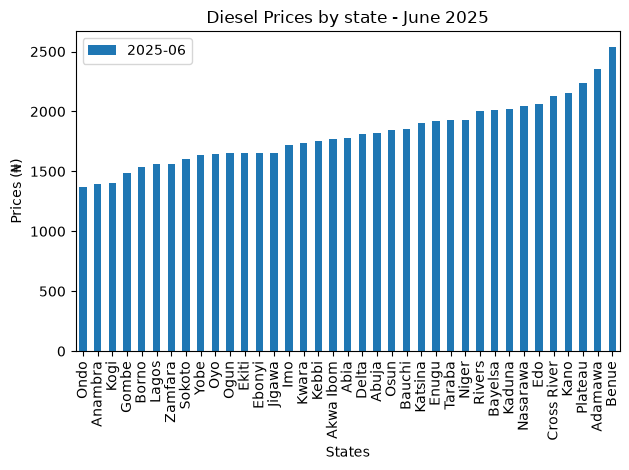

In [11]:
diesel_master.sort_values("2025-06").plot(x="State", y="2025-06", kind="bar")
plt.title("Diesel Prices by state - June 2025")
plt.xlabel("States")
plt.ylabel("Prices (₦)")
plt.tight_layout()
plt.savefig("../data/processed/charts/diesel_june2025_bystate.png")
plt.show()

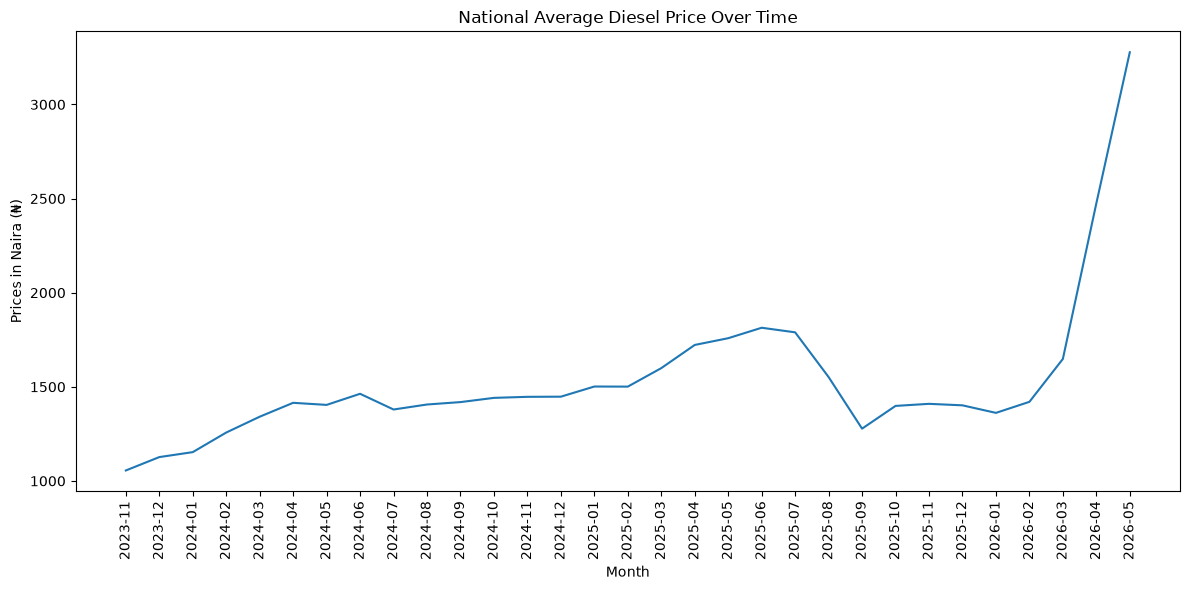

In [25]:
monthly_avg = diesel_master[diesel_master.columns[1:]].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values)

plt.title("National Average Diesel Price Over Time")
plt.xlabel("Month")
plt.ylabel("Prices in Naira (₦)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("../data/processed/charts/diesel_national_avg_trend.png")
plt.show()

In [20]:
diesel_master[diesel_master.columns[1:]].mean()

2023-11    1055.568921
2023-12    1126.690782
2024-01    1153.005989
2024-02    1257.061079
2024-03    1341.159191
2024-04    1415.058963
2024-05    1403.962012
2024-06    1462.975227
2024-07    1379.477459
2024-08    1406.051350
2024-09    1418.831129
2024-10    1441.284411
2024-11    1446.832275
2024-12    1447.615056
2025-01    1501.575015
2025-02    1501.054308
2025-03    1599.300535
2025-04    1722.453310
2025-05    1758.256160
2025-06    1813.808722
2025-07    1789.450570
2025-08    1551.881088
2025-09    1277.809061
2025-10    1398.574944
2025-11    1409.611306
2025-12    1401.629583
2026-01    1361.571222
2026-02    1420.171718
2026-03    1648.082640
2026-04    2474.690141
2026-05    3277.473902
dtype: float64